Wersja TensorFlow: 2.20.0

--- UCZENIE MODELU LINIOWEGO ---
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 391.8600 
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.6599
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3765 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2249
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8447
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4857
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3777
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3463
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3400
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3415
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3416
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3363
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3319
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3413
Epoch 

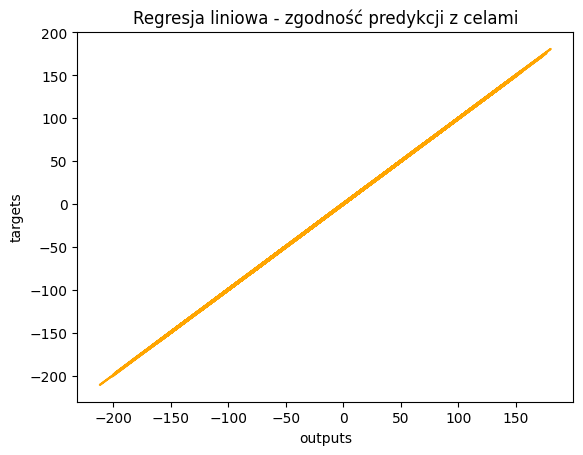


--- UCZENIE MODELU NIELINIOWEGO (Ćwiczenie 3) ---
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5316.4072
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2863.5925
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2011.7605 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1588.4722 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1472.9598
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1231.8704 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1164.2662
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1104.5442 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1057.0850
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1053.3152
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1024.6931
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1014.9412
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1002.4423
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(f"Wersja TensorFlow: {tf.__version__}")

training_data = np.load('TF_dataset.npz')
inputs = training_data['inputs'][:1000]
targets = training_data['targets'][:1000]

input_size = 2
output_size = 1

print("\n--- UCZENIE MODELU LINIOWEGO ---")
model = tf.keras.Sequential([
    tf.keras.layers.Dense(output_size)
])
model.compile(optimizer='sgd', loss='mean_squared_error')
model.fit(inputs, targets, epochs=100, verbose=1)

print("\nWagi i biasy modelu liniowego:")
print(model.layers[0].get_weights())

plt.plot(np.squeeze(model.predict_on_batch(inputs)),
         np.squeeze(targets), color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.title('Regresja liniowa - zgodność predykcji z celami')
plt.show()

print("\n--- UCZENIE MODELU NIELINIOWEGO (Ćwiczenie 3) ---")
model_nonlinear = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="sigmoid"),
    tf.keras.layers.Dense(5, activation="sigmoid"),
    tf.keras.layers.Dense(output_size)
])

model_nonlinear.compile(optimizer='sgd', loss='mean_squared_error')
model_nonlinear.fit(inputs, targets, epochs=100, verbose=1)

### Krótkie wnioski
- Model liniowy daje prosty punkt odniesienia, ale nie zawsze dobrze odwzorowuje zależności w danych.
- Model nieliniowy ma większą elastyczność i zwykle lepiej dopasowuje bardziej złożone relacje.
- Wyniki uczenia warto analizować razem z wykresem i wagami, bo same komunikaty z treningu są mało czytelne.